## Final cleaning of metadata for Zambia




### Goal
- Produce a final dataframe that has all the samples that were included in the study
- We would need the following minimal columns:
```
study | sample_id | province | district| ward | healthfac | lat | long | collection_date | rdt_result | parasitemia | take_for_sequencing | screening_method 

```

- **Primary aim:** Create a *complete as possible* metadata file that will allow accurate computation of prevalence across districts/provinces
- **Secondary aim:** Create a *complete as possible* metadata file that will allow evaluation of 'study completion' and 'sequencing passing rates'; so, for exmaple, this should help us define *what* samples were selected for sequencing and how, how many of these were actually sequenced, and what the pass rate was. The most important point of doing this is reporting in the manuscript, and to be aware of any potential biases caused by sample inclusion procedures.

### Strategy
- Load the PET-PCR and 18S results separately
- Based on conversation with Mulenga, create a new column that encodes whether or not the sample 'should' have been taken for sequencing (`take_for_sequencing`), given results from the PCR confirmations
- Merge PET-PCR and 18S tables together, and filter to only those that should have been sequenced
  - This becomes the final metadata file


In [295]:
import os
import numpy as np
import pandas as pd
import missingno

import matplotlib.pyplot as plt
import seaborn as sns

In [296]:
def standardise_columns(c: str) -> str:
    return c.lower().replace(" ", "_").strip()

## Settings

In [297]:
SAVE_RESULTS = True
INPUT_PCR_DIR = "../metadata/2025-12-17_pcr-inclusion-data-mm/csv/"
INPUT_METADATA_DIR = "../metadata/2025-12-11_study-metdata-djb"
OUTPUT_PCR_DIR = "../metadata/2025-12-17_pcr-inclusion-data-mm/csv_processed/"
OUTPUT_FINAL_DIR = "../metadata/2026-01-23_consolidated-metadata"
os.makedirs(OUTPUT_PCR_DIR, exist_ok=True)
os.makedirs(OUTPUT_FINAL_DIR, exist_ok=True)

### PCR data

*PET-PCR results*

In [298]:
kwargs = dict(dtype={'Lab ID': str, 'sample_id': str})

In [299]:
df_pethrp = pd.read_csv(f"{INPUT_PCR_DIR}/pet-pcr_results_hrp2_survey.csv", **kwargs)
df_petmis = pd.read_csv(f"{INPUT_PCR_DIR}/pet-pcr_results_mis2024.csv", **kwargs)

In [300]:
for df in [df_pethrp, df_petmis]:
    df.columns = [standardise_columns(c) for c in df.columns]
    df.rename({"result": "genus_result",
               "cp_value": "genus_cp",
               "result.1": "pf_result",
               "cp_value.1": "pf_cp",
               "lab_id": "sample_id"
              },
              axis=1, inplace=True
             )
    df.replace({"Positive": "pos", "Negative": "neg", "Repeat": "repeat"}, inplace=True)
    df.drop([c for c in df.columns if "target" in c], axis=1, inplace=True)

In [301]:
print(df_pethrp.columns)
print(df_petmis.columns)

Index(['experimentid', 'user', 'date', 'sop_name', 'sop_number', 'sop_version',
       'sample_id', 'extraction_id', 'genus_result', 'genus_cp', 'pf_result',
       'pf_cp'],
      dtype='str')
Index(['sample_id', 'extraction_id', 'genus_result', 'genus_cp', 'pf_result',
       'pf_cp'],
      dtype='str')


In [302]:
df_pethpr_update = pd.read_csv(f"{INPUT_PCR_DIR}/2026-01-29_hrp2_pet-pcr_results.csv", **kwargs)

In [303]:
df_pethpr_update.columns = [standardise_columns(c) for c in df_pethpr_update.columns]
df_pethpr_update.rename({"result_0": "genus_result",
            "cp_value_0": "genus_cp",
            "result_1": "pf_result",
            "cp_value_1": "pf_cp",
            },
            axis=1, inplace=True
            )
df_pethpr_update.replace({"Positive": "pos", "Negative": "neg", "Repeat": "repeat"}, inplace=True)
df_pethpr_update.drop([c for c in df_pethpr_update.columns if "target" in c], axis=1, inplace=True)
df_pethpr_update.dropna(subset=["genus_result"], inplace=True)
df_pethpr_update.fillna(value={"pf_result": "neg"}, inplace=True)
df_pethpr_update.columns

Index(['study', 'sample_id', 'province', 'district', 'ward', 'healthfac',
       'lat', 'long', 'collection_date', 'rdt_result', 'parasitemia',
       'extraction_id', 'pcr_status', 'genus_result', 'genus_cp', 'pf_result',
       'pf_cp'],
      dtype='str')

In [304]:
df_pethpr_update["pf_result"].value_counts(dropna=False)

pf_result
pos       67
neg        5
repeat     1
Name: count, dtype: int64

In [305]:
df_pethrp["pf_result"].value_counts(dropna=False)

pf_result
pos       545
neg       193
repeat     53
Name: count, dtype: int64

In [306]:
KEEP_COLUMNS = ['sample_id', 'extraction_id', 'genus_cp', 'genus_result', 'pf_cp', 'pf_result']
shared_columns = set(df_pethrp.columns).intersection(df_petmis.columns)

In [307]:
set(KEEP_COLUMNS).difference(shared_columns)

set()

In [308]:
df_pethrp = df_pethrp[KEEP_COLUMNS]
df_pethrp.insert(0, "study", "HRP23")

df_petmis = df_petmis[KEEP_COLUMNS]
df_petmis.insert(0, "study", "MIS2024")

df_pethpr_update = df_pethpr_update[KEEP_COLUMNS]
df_pethpr_update.insert(0, "study", "HRP23")

In [309]:
df_pet = pd.concat([df_pethrp, df_petmis, df_pethpr_update])

In [310]:
# Fix missing sample IDs
print(f"Missing sample IDs: {df_pet["sample_id"].isna().sum()}")
print(f"Duplicated sample IDs: {df_pet["sample_id"].duplicated().sum()}")
print(f"Missing extraction IDs: {df_pet["extraction_id"].isna().sum()}")
_ID = {eid: sid for eid, sid in zip(df_pet["extraction_id"], df_pet["sample_id"])
       if not pd.isna(sid)}
len(_ID), df_pet.shape

Missing sample IDs: 34
Duplicated sample IDs: 40
Missing extraction IDs: 0


(1869, (1910, 7))

In [311]:
# Replace missing from dictionary, if available
df_pet["sample_id"] = [sid if not pd.isna(sid) else _ID.get(eid) for eid, sid in zip(df_pet["extraction_id"], df_pet["sample_id"])]
print(f"Missing sample IDs: {df_pet["sample_id"].isna().sum()}") # fixed

Missing sample IDs: 0


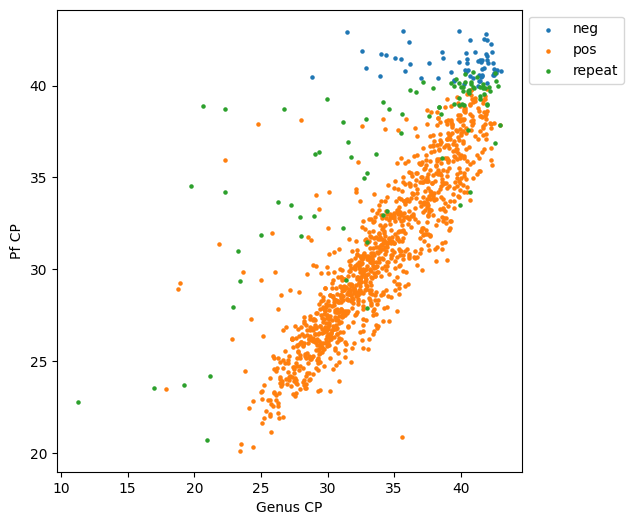

In [312]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

for c, cdf in df_pet.groupby("pf_result"):
    ax.scatter(
        x=cdf["genus_cp"],
        y=cdf["pf_cp"],
        s=5,
        label=c
    )
ax.set_xlabel("Genus CP")
ax.set_ylabel("Pf CP")
ax.legend(bbox_to_anchor=(1, 1), loc="upper left")

In [313]:
df_pet[["sample_id"]].duplicated().sum() # duplications

np.int64(41)

In [314]:
df_pet.query("pf_result != 'repeat' and genus_result != 'repeat'", inplace=True)

In [315]:
df_pet[["sample_id"]].duplicated().sum() # still we have duplications

np.int64(8)

In [316]:
dup_ids = set(df_pet[df_pet[["sample_id"]].duplicated()]["sample_id"])

In [317]:
df_pet.query("sample_id in @dup_ids").sort_values("sample_id")
# These look like jsut accidentally duplicated rows, we can drop them

,study,sample_id,extraction_id,genus_cp,genus_result,pf_cp,pf_result
327,MIS2024,8010821,DV289,NaN,neg,NaN,neg
328,MIS2024,8010821,DV289,NaN,neg,NaN,neg
110,MIS2024,8031566,DV1000,31.245,pos,29.455,pos
1039,MIS2024,8031566,DV1000,31.245,pos,29.455,pos
111,MIS2024,8031567,DV1001,28.030,pos,26.035,pos
1040,MIS2024,8031567,DV1001,28.030,pos,26.035,pos
112,MIS2024,8031569,DV1002,40.760,neg,39.735,pos
1041,MIS2024,8031569,DV1002,40.760,neg,39.735,pos
114,MIS2024,8031572,DV1004,30.980,pos,29.580,pos
1042,MIS2024,8031572,DV1004,30.980,pos,29.580,pos


In [318]:
df_pet = df_pet.drop_duplicates()

In [319]:
df_pet = df_pet.reset_index(drop=True)

In [320]:
pd.crosstab(
    df_pet["study"],
    df_pet["pf_result"],
    margins='All'
)

pf_result,neg,pos,All
study,,,
HRP23,185,559,744
MIS2024,404,470,874
All,589,1029,1618


In [321]:
pd.crosstab(
    df_pet["pf_result"],
    df_pet["genus_result"],
    margins='All'
)

genus_result,neg,pos,All
pf_result,,,
neg,557,32,589
pos,79,950,1029
All,636,982,1618


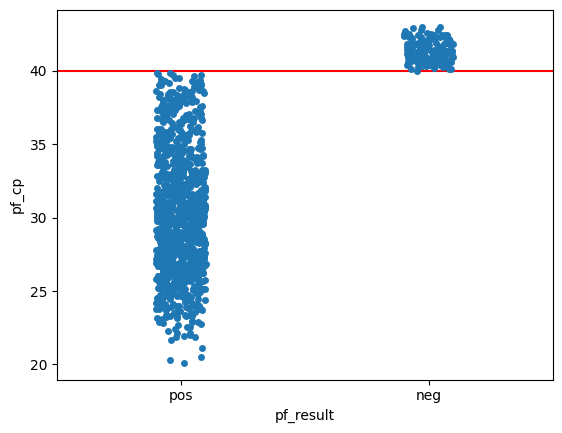

In [322]:
fig, ax = plt.subplots(1, 1)

sns.stripplot(
    x="pf_result",
    y="pf_cp",
    data=df_pet
)

ax.axhline(40, color='red')

- At cycle 40 you can see the switch from postive to negative

In [323]:
def include_based_on_petpcr(row: pd.Series) -> bool:
    """
    Encode whether we should include the sample
    based on the PET-PCR results

    - pf_pos if cp < 40
    - however, only included IF pf_cp <= 36

    genus columns was not used
    repeat also not used, just ignore

    """
    return row['pf_cp'] <= 36 # this is the only criteria!

In [324]:
df_pet["take_for_sequencing"] = df_pet.apply(include_based_on_petpcr, axis=1)
df_pet["screening_method"] = "pet_pcr"

*18S PCR*

In [325]:
dfs = []
for csv in os.listdir(INPUT_PCR_DIR):
    if not csv.startswith("snou"):
        continue
    df = pd.read_csv(f"{INPUT_PCR_DIR}/{csv}", dtype=str)
    df.columns = [standardise_columns(c) for c in df.columns]
    df.rename({"ext_id": "extraction_id",
               "lab_id": "sample_id",
               "pcr_result": "pf_convpcr",
               "results": "pf_convpcr",
          },
          axis=1, inplace=True
         )
    df = df.replace({"Positive": "pos", "Negative": "neg"})
    dfs.append(df[["sample_id", "extraction_id", "pf_convpcr"]])

In [326]:
df_snou = pd.concat(dfs)
df_snou.insert(0, "study", "HRP23")

In [327]:
def include_based_on_convpcr(row: pd.Series) -> bool:
    """
    Encode whether we should include the sample
    based on the Snounou results

    Just include if positive

    """
    return row['pf_convpcr'] == 'pos'

In [328]:
df_snou["take_for_sequencing"] = df_snou.apply(include_based_on_convpcr, axis=1)
df_snou["screening_method"] = "18s_pcr"

In [329]:
df_pcr = pd.concat([df_pet, df_snou], axis=0)

In [330]:
df_pcr = df_pcr.reset_index(drop=True)

In [331]:
pd.crosstab(
    df_pcr["take_for_sequencing"],
    df_pcr["screening_method"],
    margins='All',
    dropna=False
)

screening_method,18s_pcr,pet_pcr,All
take_for_sequencing,,,
False,622,703,1325
True,1690,915,2605
All,2312,1618,3930


Now we need to compute two columns:
- `take_for_sequencing` -- should this sample have been taken forward for sequencing? (True, False)
- `screening_method` -- if so, on the basis of what information? (`18s_pcr`, `pet_pcr`)

<Axes: >

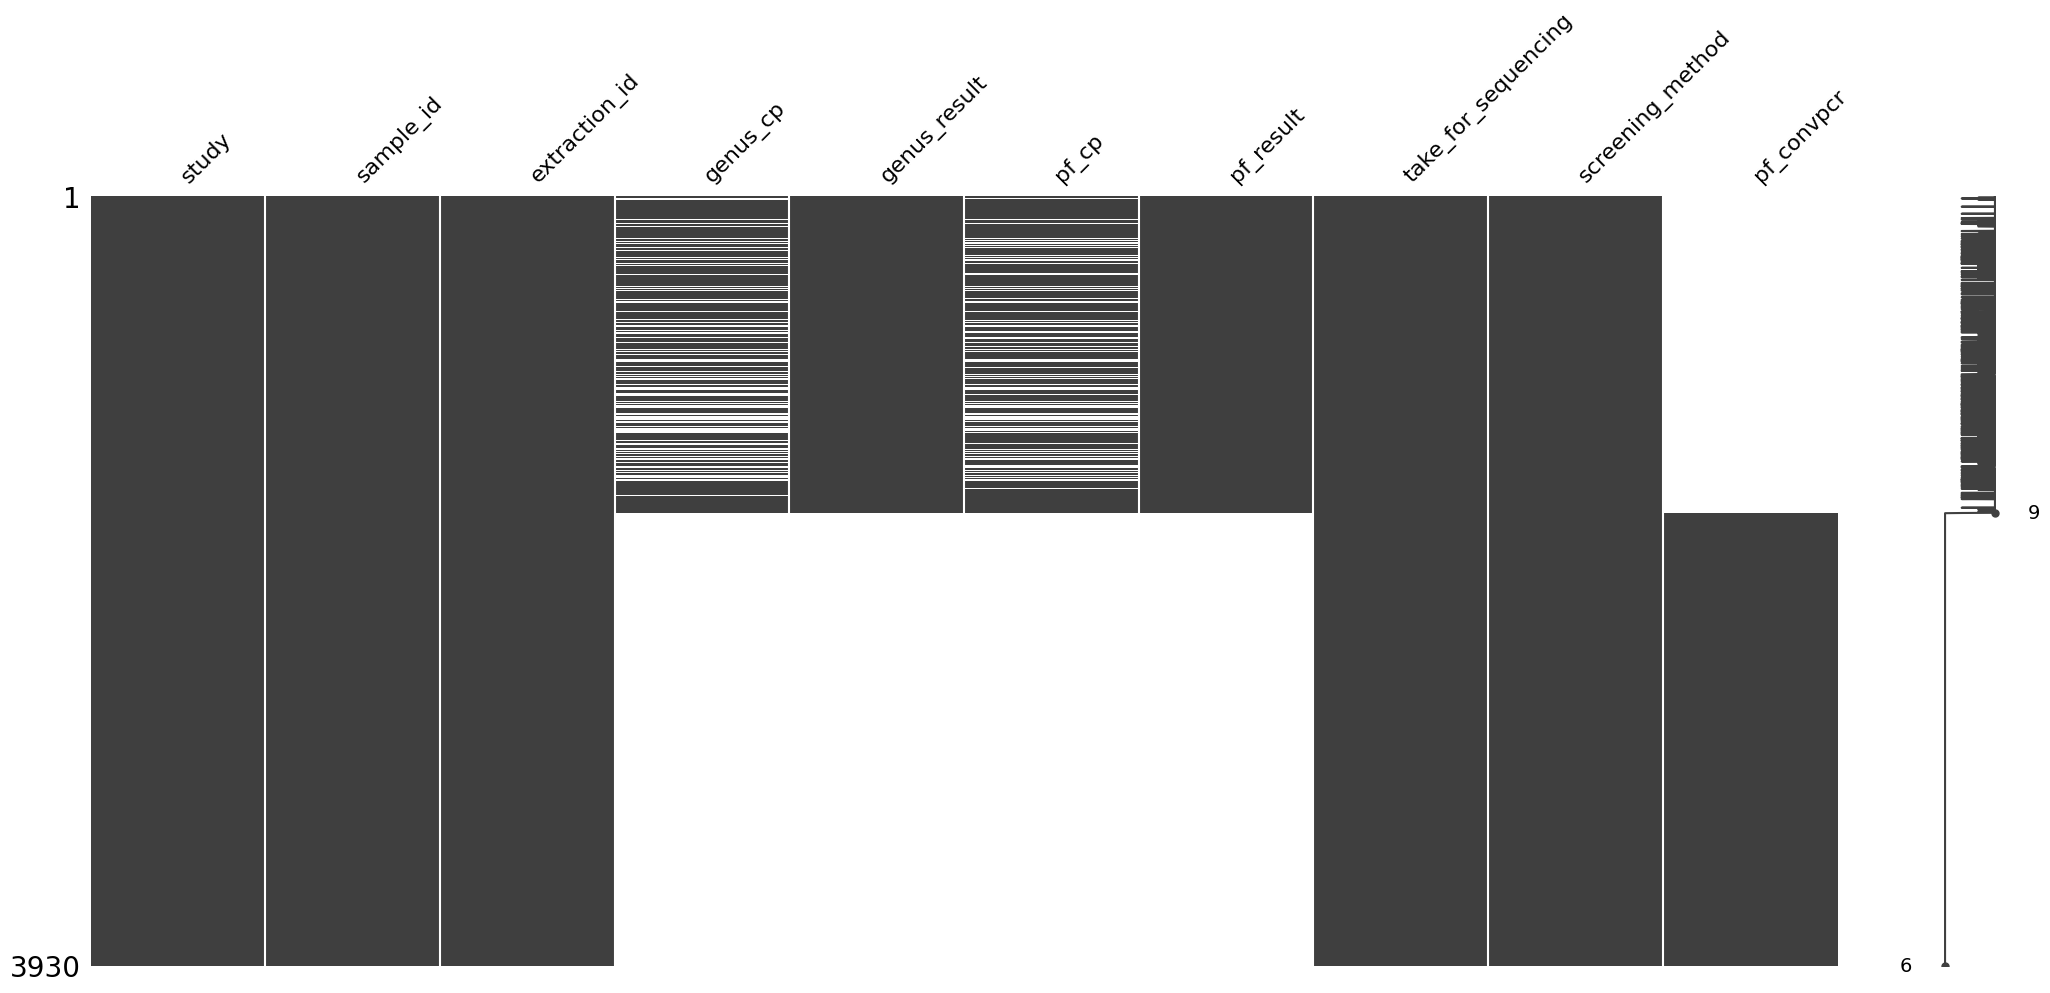

In [332]:
missingno.matrix(df_pcr)

*Below is legacy, fixed above now*

In [333]:
df_pcr[["sample_id"]].duplicated().sum()

np.int64(0)

In [334]:
df_pcr[["sample_id"]].isna().sum()

sample_id    0
dtype: int64

In [335]:
df_pcr[df_pcr[["sample_id"]].duplicated()] # most duplicated are missing

,study,sample_id,extraction_id,genus_cp,genus_result,pf_cp,pf_result,take_for_sequencing,screening_method,pf_convpcr


*Explore duplications a bit*

In [336]:
duplicated_ids = set(df_pcr[df_pcr["sample_id"].duplicated() & ~df_pcr["sample_id"].isna()]["sample_id"])

In [337]:
df_pcr.query("sample_id in @duplicated_ids").sort_values("sample_id") # duplicated, but probably can just remove.

,study,sample_id,extraction_id,genus_cp,genus_result,pf_cp,pf_result,take_for_sequencing,screening_method,pf_convpcr


*Explore missing a bit*

In [338]:
missing_extract_ids = set(df_pcr[df_pcr.sample_id.isna()]["extraction_id"])

In [339]:
df_snou.query("extraction_id in @missing_extract_ids")

,study,sample_id,extraction_id,pf_convpcr,take_for_sequencing,screening_method


In [340]:
df_petmis.query("extraction_id in @missing_extract_ids").shape

(0, 7)

In [341]:
len(missing_extract_ids) # wow

0

In [342]:
df_petmis.query("extraction_id in @missing_extract_ids").head() # here is the issue, they are duplicated, once with once without sample ID

,study,sample_id,extraction_id,genus_cp,genus_result,pf_cp,pf_result


- Okay, I solved the issue (added cells above)!
- In most cases, these are *repeated* **PET-PCR results**
    - For some reason, they *did* not populate the sample_id for the repeat
      - So the initial outcome was 'repeat'
      - then after that it got an outcome, but not a sample ID
- More importantly, the missing sample IDs can be filled
  - By linking with the extraction ID
- And then we can simply remove all the 'repeat' outcomes

In [343]:
if SAVE_RESULTS:
    df_pcr[df_pcr.sample_id.duplicated()].to_csv(f"{OUTPUT_PCR_DIR}/table.pcr_missing_or_duplicated_sample_id.csv", index=False)

In [344]:
pd.crosstab(df_pcr["take_for_sequencing"],
            df_pcr["study"],
            margins='All',
            dropna=False)

study,HRP23,MIS2024,All
take_for_sequencing,,,
False,862,463,1325
True,2194,411,2605
All,3056,874,3930


**Conclusions from PCR inclusion data**
- We have a total of 3509(now 3860) samples that were subjected to some sort of PCR confirmation
- We should have 2306 (now 2543) samples that would be taken forward for sequencing, according to these inclusion criterion
    - 1895 (now 2132) from HRP23
    - 411 from MIS2024

**TODO**
- Deal with duplication?
- Are we confident inclusion criteria are ~correct
  - Does it *really* matter if they are not?

In [345]:
if SAVE_RESULTS:
    df_pcr.to_csv(f"{OUTPUT_FINAL_DIR}/table.pcr_data_combined.csv", index=False)

## Metadata from Dan

Goal is to extract *at least* the following information for both studies:
```
study | sample_id | province | district| ward | healthfac | lat | long | collection_date | take_for_sequencing | screening_method | rdt_result | parasitemia 

```

*MIS2024*

In [346]:
TARGET_COLUMNS_META = ["study", "sample_id", "province", "district", "ward", "healthfac", "lat", "long", "collection_date", "parasitemia", "sequencing_set", "sequencing_set_method"] 

In [347]:
# Load
df_meta_mis = pd.read_csv(f"{INPUT_METADATA_DIR}/MIS2024.csv", dtype={'sample_id': str})

# Clean
df_meta_mis.insert(0, "study", "MIS2024")
df_meta_mis.rename({"latitude": "lat",
                    "longitude": "long",
                    "microscopy_count": "parasitemia",
                    "visit_date": "collection_date"
                   },
                   axis=1,
                   inplace=True)

In [348]:
df_meta_mis["rdt_result"] = df_meta_mis["rdt_result"].replace({"negative": "pf_neg", "pf positive": "pf_pos", "not valid": "invalid"})

In [349]:
df_meta_mis["rdt_result"].value_counts()

rdt_result
pf_neg     1678
pf_pos      935
invalid       1
Name: count, dtype: int64

In [350]:
df_meta_mis = df_meta_mis[["study", "sample_id", "province", "district", "ward", "lat", "long", "collection_date", "rdt_result", "parasitemia"]]

<Axes: >

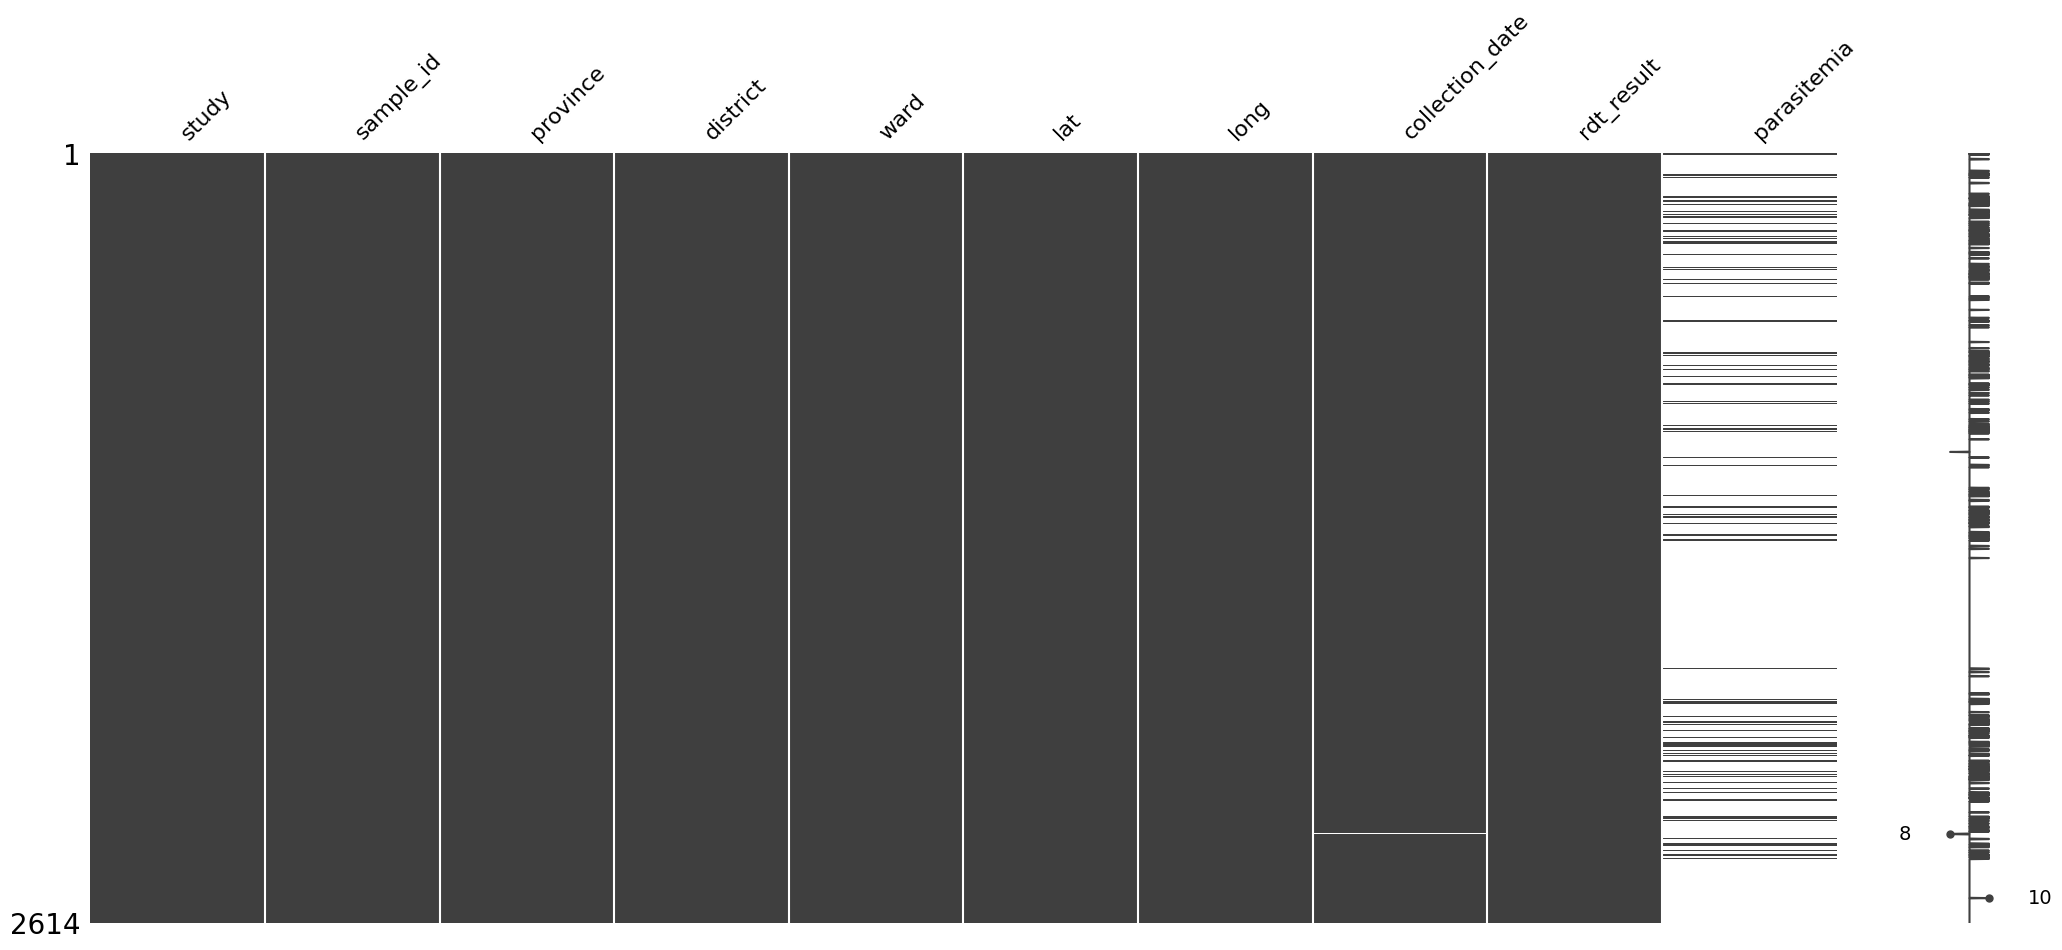

In [351]:
missingno.matrix(df_meta_mis) # all good but parasitemia

In [352]:
df_meta_summary = df_meta_mis.groupby("province").agg(
    n_samples=pd.NamedAgg("province", len),
    n_districts=pd.NamedAgg("district", lambda x: len(set(x))),
    n_rdt_pos=pd.NamedAgg("rdt_result", lambda x: sum(x == "pf_pos"))
)
df_meta_summary.loc['TOTAL'] = df_meta_summary.sum()
df_meta_summary["pfpr"] = round(100 * df_meta_summary["n_rdt_pos"] / df_meta_summary["n_samples"], 1)
df_meta_summary

,n_samples,n_districts,n_rdt_pos,pfpr
province,,,,
central,248,9,92,37.1
copperbelt,329,9,155,47.1
eastern,594,15,190,32.0
luapula,230,10,151,65.7
lusaka,305,6,21,6.9
muchinga,119,8,65,54.6
northern,187,10,105,56.1
northwestern,116,10,81,69.8
southern,300,15,3,1.0


In [353]:
df_meta_mis.sample_id.duplicated().sum() # no duplication

np.int64(0)

In [354]:
df_meta_mis[~df_meta_mis.sample_id.str.match(r"[0-9]+")] # no wrong looking IDs

,study,sample_id,province,district,ward,lat,long,collection_date,rdt_result,parasitemia


*HRP23*

In [355]:
def get_rdt_result(test: str, control: str) -> str:
    if test is None or control is None:
        return None
    if control != "positive":
        return "invalid"
    return "pf_pos" if test =="positive" else "pf_neg"

In [356]:
# Load
df_meta_hrp = pd.read_csv(f"{INPUT_METADATA_DIR}/hrp2_2024.csv", dtype={'sample_id': str})

# Clean
df_meta_hrp.insert(0, "study", "HRP23")
df_meta_hrp["rdt_result"] = [get_rdt_result(t, c) for t, c in zip(df_meta_hrp["hrp2onlyrdt_hrp2line"], df_meta_hrp["hrp2onlyrdt_controlline"])] # confirmed /w mulenga this is how it was done
df_meta_hrp.rename({"latitude": "lat",
                    "longitude": "long",
                    "microscopy_density": "parasitemia",
                    "visit_date": "collection_date"
                   }, 
                   axis=1,
                   inplace=True)

In [357]:
df_meta_hrp_invalid_positive = df_meta_hrp.query("hrp2onlyrdt_controlline != 'positive' and hrp2onlyrdt_hrp2line	== 'positive'")

In [358]:
df_meta_hrp = df_meta_hrp[["study", "sample_id", "province", "district", "healthfac", "lat", "long", "collection_date", "rdt_result", "parasitemia"]]

In [359]:
df_meta_hrp.sample_id.duplicated().sum() # no duplicates

np.int64(0)

In [360]:
df_meta_hrp[~df_meta_hrp.sample_id.str.match(r"[0-9]+")] # 3 wrong looking IDs

,study,sample_id,province,district,healthfac,lat,long,collection_date,rdt_result,parasitemia
4018,HRP23,x,western,kaoma,kaoma health centre,-14.804755,24.798391,NaN,invalid,NaN
4112,HRP23,no dbs,northern,mpulungu,kasakalawe rural health centre,-8.792006,31.082831,NaN,pf_neg,NaN
4773,HRP23,missing,western,luampa,luampa mission district hospital,-15.057048,24.443362,NaN,pf_neg,NaN


In [361]:
# drop these rows
df_meta_hrp = df_meta_hrp[df_meta_hrp.sample_id.str.match(r"[0-9]+")]

<Axes: >

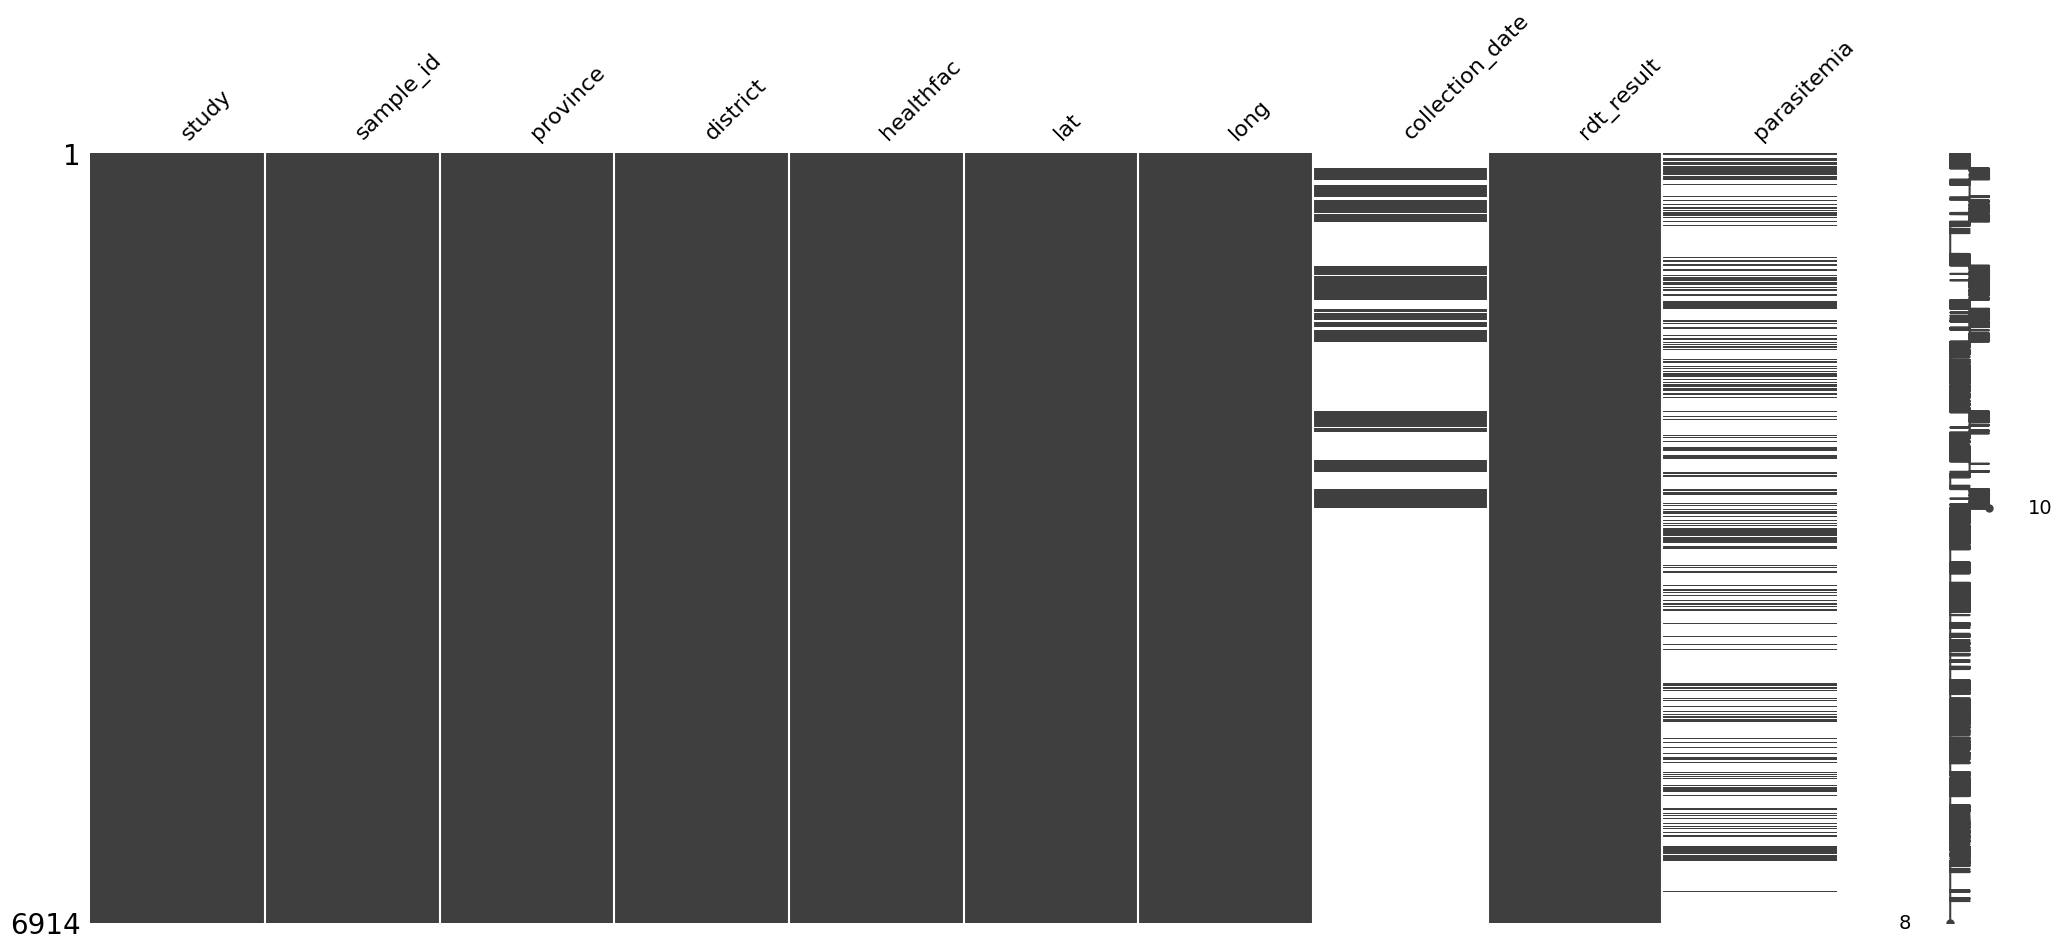

In [362]:
missingno.matrix(df_meta_hrp)

In [363]:
df_meta_summary = df_meta_hrp.groupby("province").agg(
    n_samples=pd.NamedAgg("province", len),
    n_districts=pd.NamedAgg("district", lambda x: len(set(x))),
    n_rdt_pos=pd.NamedAgg("rdt_result", lambda x: sum(x == "pf_pos"))
)
df_meta_summary.loc['TOTAL'] = df_meta_summary.sum()
df_meta_summary["pfpr"] = round(100 * df_meta_summary["n_rdt_pos"] / df_meta_summary["n_samples"], 1)
df_meta_summary

,n_samples,n_districts,n_rdt_pos,pfpr
province,,,,
central,595,6,226,38.0
copperbelt,1040,9,361,34.7
eastern,784,5,424,54.1
luapula,1079,6,679,62.9
lusaka,440,4,88,20.0
muchinga,369,4,242,65.6
northern,664,5,253,38.1
northwestern,1038,9,270,26.0
western,905,7,125,13.8


*Combine and have a look*

In [364]:
df_meta = pd.concat([df_meta_mis, df_meta_hrp], axis=0)[
    ["study", "sample_id", "province", "district", "ward", "healthfac", "lat", "long", "collection_date", "rdt_result", "parasitemia"]
]

In [365]:
df_meta.shape

(9528, 11)

In [366]:
df_meta.reset_index(drop=True, inplace=True)

In [367]:
pd.crosstab(
    df_meta["study"],
    df_meta["province"],
    margins='All',
    dropna=False
)

province,central,copperbelt,eastern,luapula,lusaka,muchinga,northern,northwestern,southern,western,All
study,,,,,,,,,,,
HRP23,595,1040,784,1079,440,369,664,1038,0,905,6914
MIS2024,248,329,594,230,305,119,187,116,300,186,2614
All,843,1369,1378,1309,745,488,851,1154,300,1091,9528


In [368]:
# Combined
df_meta_summary = df_meta.groupby("province").agg(
    n_samples=pd.NamedAgg("province", len),
    n_districts=pd.NamedAgg("district", lambda x: len(set(x))),
    n_rdt_pos=pd.NamedAgg("rdt_result", lambda x: sum(x == "pf_pos"))
)
df_meta_summary.loc['TOTAL'] = df_meta_summary.sum()
df_meta_summary["pfpr"] = round(100 * df_meta_summary["n_rdt_pos"] / df_meta_summary["n_samples"], 1)
df_meta_summary

,n_samples,n_districts,n_rdt_pos,pfpr
province,,,,
central,843,9,318,37.7
copperbelt,1369,9,516,37.7
eastern,1378,15,614,44.6
luapula,1309,11,830,63.4
lusaka,745,6,109,14.6
muchinga,488,8,307,62.9
northern,851,10,358,42.1
northwestern,1154,12,351,30.4
southern,300,15,3,1.0


<Axes: >

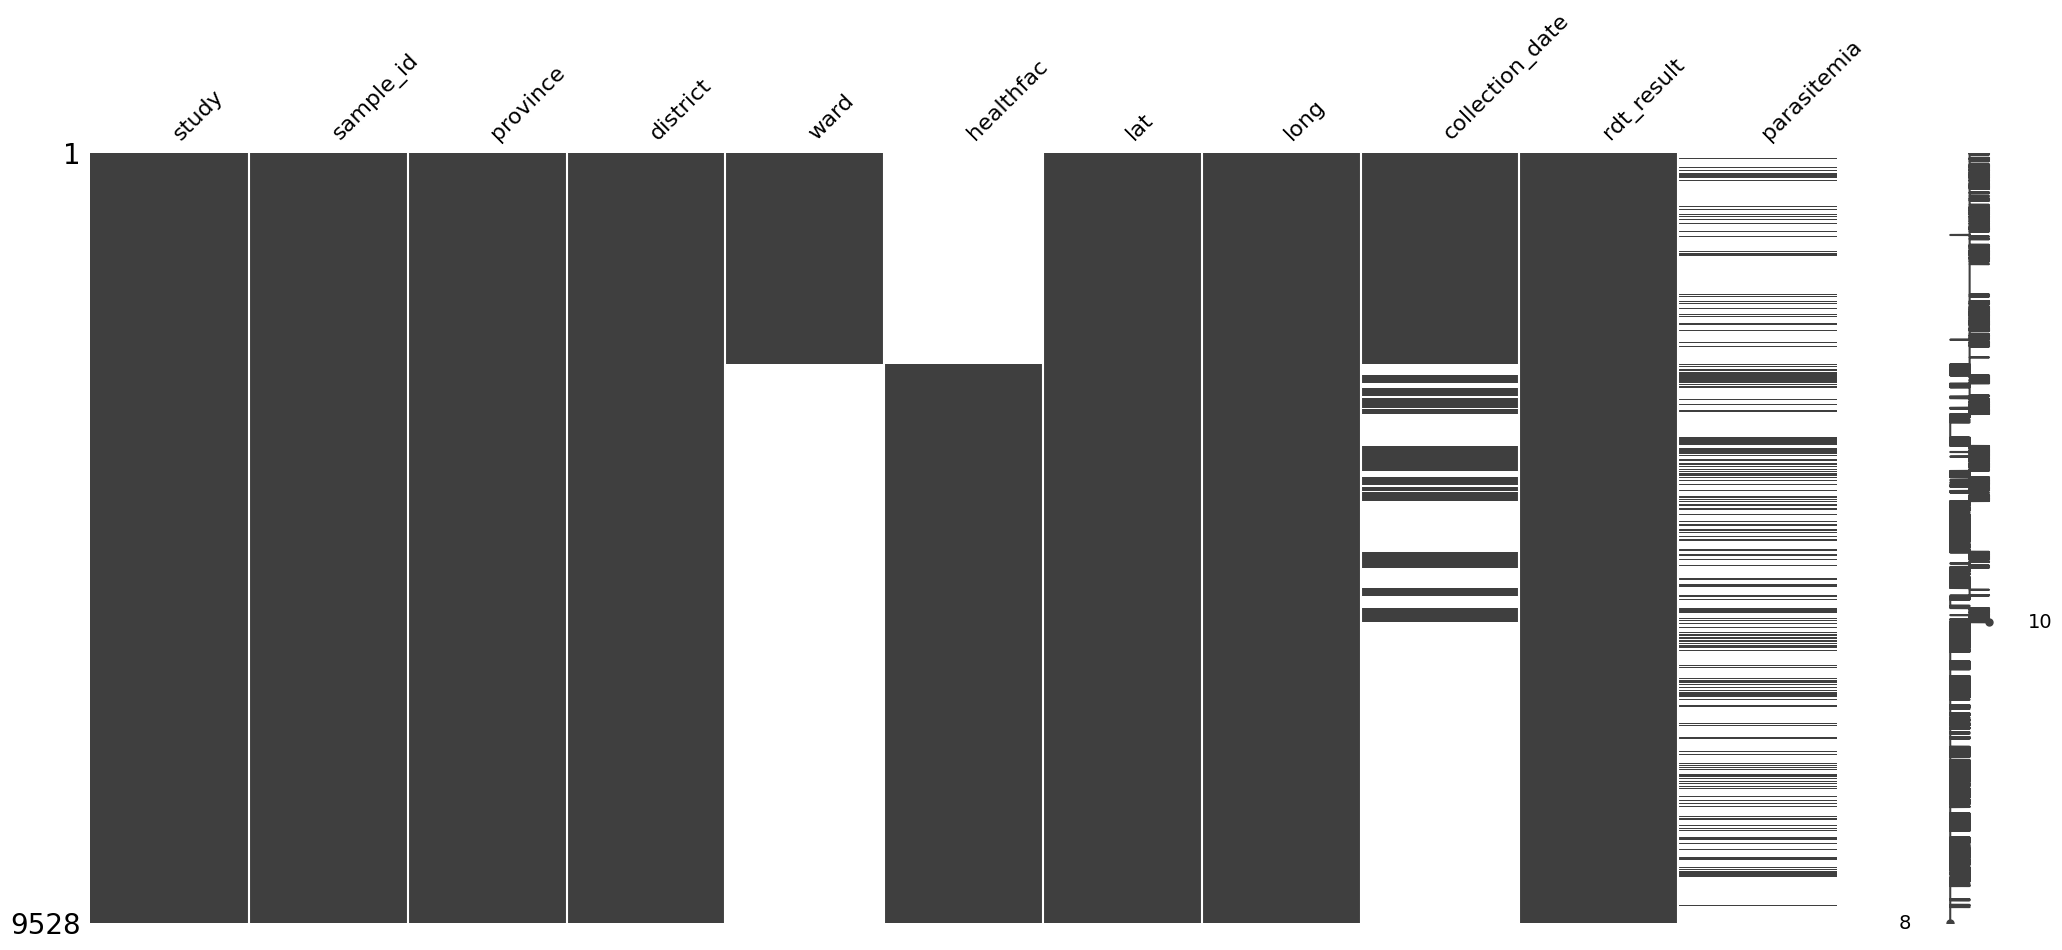

In [369]:
missingno.matrix(df_meta)

In [370]:
if SAVE_RESULTS:
    df_meta.to_csv(f"{OUTPUT_FINAL_DIR}/table.metadata_combined.csv", index=False)

## Prepare to combine with PCR data

In [371]:
PROBLEM_DIR = f"{OUTPUT_FINAL_DIR}/problematic"
os.makedirs(PROBLEM_DIR, exist_ok=True)

In [372]:
sample_ids_done_pcr = set(df_pcr.sample_id)

In [373]:
df_meta_no_pcr = df_meta.query("rdt_result == 'pf_pos'").query("sample_id not in @sample_ids_done_pcr")

In [374]:
df_meta_no_pcr.shape

(378, 11)

- 808 (down to 378) samples that are RDT positive but were not taken for PCR, why?

In [375]:
if SAVE_RESULTS:
    df_meta_no_pcr.to_csv(f"{PROBLEM_DIR}/table.pf_pos_but_not_pcr_done.csv", index=False)

In [376]:
df_meta_shouldnt_have_pcr = df_meta.query("rdt_result == 'pf_neg'").query("sample_id in @sample_ids_done_pcr")

In [377]:
if SAVE_RESULTS:
    df_meta_hrp_invalid_positive.to_csv(f"{PROBLEM_DIR}/hrp2_rdt_invalid_positive_results.csv", index=False)

In [378]:
df_meta_shouldnt_have_pcr.shape # 184 with PCR but were pf_neg

(184, 11)

In [379]:
if SAVE_RESULTS:
    df_meta_shouldnt_have_pcr.to_csv(f"{PROBLEM_DIR}/table.pf_neg_but_has_pcr.csv", index=False)

In [380]:
df_merge = pd.merge(
    left=df_meta,
    right=df_pcr[['sample_id', 'extraction_id', 'take_for_sequencing', 'screening_method']],
    on='sample_id',
    # outer first to report missing metadata
    how='outer'
)  

In [381]:
df_pcr_data_no_metadata = df_pcr[~df_pcr.sample_id.isin(df_meta.sample_id)]

In [382]:
if SAVE_RESULTS:
    df_pcr_data_no_metadata.to_csv(f"{PROBLEM_DIR}/table.pcr_data_no_metadata.csv", index=False)

In [383]:
df_merge = pd.merge(
    left=df_meta,
    right=df_pcr[['sample_id', 'extraction_id', 'take_for_sequencing', 'screening_method']],
    on='sample_id',
    # left now to not keep samples without metadata
    how='left'
)  

In [384]:
df_merge["has_pcr"] = [not pd.isna(s) for s in df_merge["screening_method"]]

In [385]:
pd.crosstab(
    df_merge["rdt_result"],
    df_merge["has_pcr"],
    dropna=False,
    margins='All'
)

has_pcr,False,True,All
rdt_result,,,
invalid,917,453,1370
pf_neg,4371,184,4555
pf_pos,378,3225,3603
All,5666,3862,9528


In [386]:
# Replace some district names to match with the naming in the mapping file used
df_merge["district"] = df_merge["district"].replace({"shang'ombo": "shangombo", "mushindano": "mushindamo"})

In [387]:
df_merge["district"].unique()

<StringArray>
['kapiri mposhi',        'mkushi',         'luano',        'mumbwa',
      'chibombo',       'serenje',      'chitambo',       'milenge',
        'chembe',         'mansa',
 ...
         'pemba',        'gwembe',         'monze',      'mazabuka',
    'chikankata',      'chirundu',      'siavonga',  'mwansabombwe',
       'kabompo',       'sesheke']
Length: 106, dtype: str

In [388]:
# Extract locations
assert (df_merge["ward"].notna() ^ df_merge["healthfac"].notna()).all()

In [389]:
df_merge["location"] = df_merge["ward"].combine_first(df_merge["healthfac"])

In [390]:
df_merge["location"].isna().sum()

np.int64(0)

In [391]:
df_merge.columns

Index(['study', 'sample_id', 'province', 'district', 'ward', 'healthfac',
       'lat', 'long', 'collection_date', 'rdt_result', 'parasitemia',
       'extraction_id', 'take_for_sequencing', 'screening_method', 'has_pcr',
       'location'],
      dtype='str')

In [392]:
check = df_merge.groupby(["location"])[["lat","long"]].nunique()
# assert (check <= 1).all().all(), "Some locations have different coordinates"

df_location = df_merge.drop_duplicates(["location"])[["location", "lat", "long"]]

In [393]:
df_location.to_csv(f"{OUTPUT_FINAL_DIR}/locations.csv", index=False)

- Will have some issues with duplication, but otherwise, here it is

In [394]:
if SAVE_RESULTS:
    df_merge.to_csv(f"{OUTPUT_FINAL_DIR}/table.zambia_all_data_combined.csv", index=False)

## Filter to those taken for sequencing

In [395]:
df_seq = df_merge.query("take_for_sequencing == True").sort_values(["study", "province", "district", "ward", "healthfac"])

In [396]:
pd.crosstab(df_seq['study'],
            df_seq['rdt_result'],
            margins=True)

rdt_result,invalid,pf_neg,pf_pos,All
study,,,,
HRP23,338,51,1795,2184
MIS2024,1,0,385,386
All,339,51,2180,2570


In [397]:
pd.crosstab(df_seq['study'],
            df_seq['province'],
            margins=True)

province,central,copperbelt,eastern,luapula,lusaka,muchinga,northern,northwestern,southern,western,All
study,,,,,,,,,,,
HRP23,186,301,388,417,89,149,225,138,0,291,2184
MIS2024,24,50,64,65,10,34,56,45,1,37,386
All,210,351,452,482,99,183,281,183,1,328,2570


In [398]:
df_seq.sample_id.duplicated().sum() # no duplicates

np.int64(0)

<Axes: >

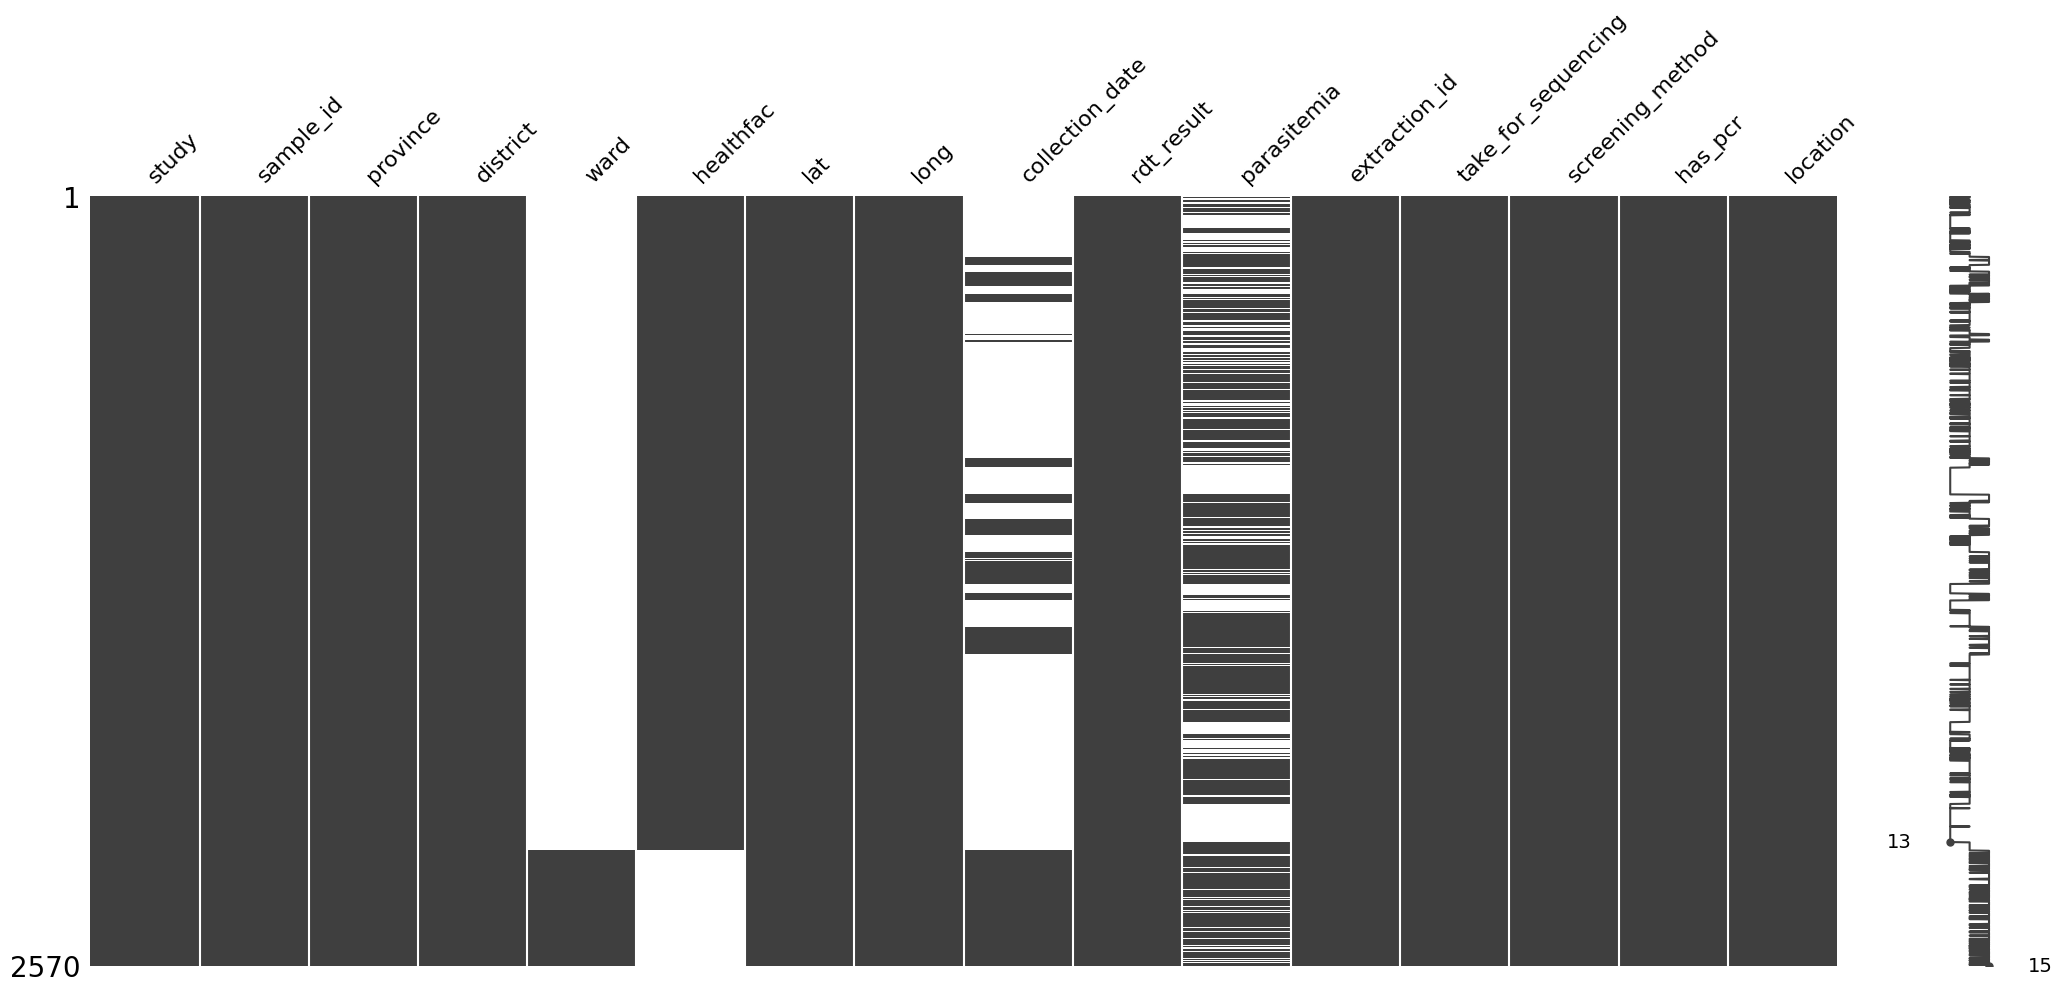

In [399]:
missingno.matrix(df_seq)

**Remove facilities with issues**
- For these districts, there was *some* evidence samples were duplicated
- Removing the entire district is the safest approach, but we do lose a lot of data
- We could consider selectively removing samples with clear evidence of duplication

In [400]:
dubious_districts = [
    "nkeyema",
    "kalumbila"
] # these look to have sample duplication
print(f"Dubious samples lost: {df_seq.query('district in @dubious_districts').shape[0]}")
df_seq = df_seq.query("district not in @dubious_districts")

Dubious samples lost: 56


In [401]:
if SAVE_RESULTS:
    df_seq.to_csv(f"{OUTPUT_FINAL_DIR}/table.zambia_master_metdata.provisional.csv", index=False)

In [402]:
# Combined
df_meta_summary = df_seq.groupby("province").agg(
    n_samples=pd.NamedAgg("province", len),
    n_districts=pd.NamedAgg("district", lambda x: len(set(x))),
    n_rdt_pos=pd.NamedAgg("rdt_result", lambda x: sum(x == "pf_pos"))
)
df_meta_summary.loc['TOTAL'] = df_meta_summary.sum()
df_meta_summary["pfpr"] = round(100 * df_meta_summary["n_rdt_pos"] / df_meta_summary["n_samples"], 1)
df_meta_summary

,n_samples,n_districts,n_rdt_pos,pfpr
province,,,,
central,210,8,171,81.4
copperbelt,351,9,321,91.5
eastern,452,14,427,94.5
luapula,482,11,481,99.8
lusaka,99,4,67,67.7
muchinga,183,8,183,100.0
northern,281,10,214,76.2
northwestern,153,9,149,97.4
southern,1,1,1,100.0


- This is just for 'should have been sequenced' samples